Evet, bu çok yaygın bir durum: **SVM doğrusal (linear) sınıflarda başarılı** ama **doğrusal olmayan (non-linear)** sınıflarda başarısı düşebilir.
Tam bu noktada devreye giren güçlü çözüm:

---

# 🔷 Kernel SVM (Çekirdekli Destek Vektör Makinesi)

---

## 📌 Tanım:

**Kernel SVM**, doğrusal olarak ayrılamayan veriler için geliştirilmiş **SVM’in daha esnek bir versiyonudur.**
Amaç:

> Verileri **daha yüksek boyutlu bir uzaya** dönüştürerek, orada doğrusal ayırma yapmak!

Yani:

> **2D’de ayrılamayan verileri 3D uzaya atıp düz çizgi gibi ayırmak.**

---

## 🎯 Neden Kernel?

Veri şu şekildedir diyelim:

```
Sınıf 0: ●●●
        ○○○
Sınıf 1:      ○○○

Bunlar doğrusal bir çizgiyle ayrılamaz!
```

Ama bir fonksiyonla bu veriyi dönüştürürsek:

* Veri **daha yüksek boyutta** daha kolay ayrılabilir hale gelir.
* Bu dönüşüme "**kernel trick**" denir.

---

## 🧠 Kernel Trick Nedir?

Verileri **gerçekte dönüştürmeden**, matematiksel olarak **iç çarpım hesaplarıyla** yüksek boyutta işlem yapabilmeyi sağlar.

> Yani yüksek boyuta çıkmak için ekstra maliyete katlanmayız!

---

## 🔧 Kullanılan Kernel Türleri:

| Kernel Türü        | Açıklama                                        | Uygun Olduğu Durum         |
| ------------------ | ----------------------------------------------- | -------------------------- |
| `'linear'`         | Doğrusal sınırlar                               | Doğrusal ayrılabilir veri  |
| `'poly'`           | Polinom dönüşümü (X², X³ gibi)                  | Parabolik yapılar          |
| `'rbf'` (Gaussian) | En yaygın – karmaşık yapılar, kıvrımlı sınırlar | Gerçek hayattaki çoğu veri |
| `'sigmoid'`        | Nadir kullanılır, yapay sinir ağına benzer      | Özel durumlar              |

### ✅ Eğitimlerde genelde **RBF kernel** kullanılır çünkü çok esnektir.

---

## 💻 Python Örneği (RBF Kernel ile):

```python
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Veri ölçeklenmeli!
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Kernel SVM
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred = svm_rbf.predict(X_test_scaled)
```

---

## 📈 Karar Sınırları – Nasıl Değişir?

* `linear kernel`: düz çizgi
* `rbf kernel`: kıvrımlı, yuvarlak, kompleks sınırlar çizebilir
* Yani Kernel SVM, **çok karmaşık ayırımlar** yapabilir.

---

## 🎯 SVM vs Kernel SVM Karşılaştırması

| Özellik        | SVM (Linear)       | Kernel SVM (RBF/poly) |
| -------------- | ------------------ | --------------------- |
| Ayrım tipi     | Düz çizgi (lineer) | Eğri/kıvrımlı ayrım   |
| Esneklik       | Az                 | Yüksek                |
| Karmaşık veri  | Başarısız olabilir | Başarı artar          |
| Hesap maliyeti | Daha düşük         | Daha yüksek           |

---

## ⚠️ Dikkat Edilmesi Gerekenler:

1. **Veri mutlaka ölçeklenmelidir!**
   RBF kernel mesafelere çok duyarlıdır.

2. **Overfitting riski olabilir.**
   Çok esnek olduğu için tüm veriyi öğrenebilir, genelleme bozulabilir.

---

## 🎓 Özetle:

* Kernel SVM, **doğrusal olmayan sınıflandırma problemlerinde** çok güçlü bir çözümdür.
* RBF kernel, SVM’in sınırlarını aşmasını sağlar.
* Model, yüksek boyutta çizgisel ayırımı **görünmeyen şekilde yapar**.

---

Videoda bu konu genelde **2D görselleştirmeyle gösterilir** (kıvrımlı sınırlar gibi).
İzledikten sonra istersen birlikte uygulama yaparak bu farkı net şekilde gösterebiliriz.

Sonraki konu: **Naive Bayes** olacak. Ona geçtiğinde yine desteklerim! Hazırsan geçelim mi?

Şimdi bir otomobil şirketi yeni bir otomobil piyasaya sürmüş olsun ve hangi eski müşterilerin bu ürünü alma mihtimali yüksek olacağını tahmin etmeni istiyor, verilerde yaş tahmini maaş ve önceden suv alan veya almayanlar 0 1 olarak



## Importing the libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [9]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Kernel SVM model on the Training set

In [12]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

## Predicting a new result

In [13]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


## Predicting the Test set results

In [15]:
y_pred = classifier.predict(X_test) # sağdaki gerçek değer soldaki modelin tahmini
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


## Making the Confusion Matrix

### 📌 Açıklamaları:

| Terim | Anlamı                                                                |
| ----- | --------------------------------------------------------------------- |
| TP    | Gerçek sınıf 1, model de 1 tahmin etti (doğru)                        |
| TN    | Gerçek sınıf 0, model de 0 tahmin etti (doğru)                        |
| FP    | Gerçek sınıf 0, ama model 1 dedi (yanlış pozitif — yanlış alarm)      |
| FN    | Gerçek sınıf 1, ama model 0 dedi (yanlış negatif — gözden kaçan vaka) |

---

### 💻 Python Örneği:

```python
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 0, 1, 0, 1]
y_pred = [1, 0, 1, 0, 0, 1, 1]

cm = confusion_matrix(y_true, y_pred)
print(cm)
```

Çıktı örneği:

```
[[2 1]
 [1 3]]
```

* TN = 2, FP = 1
* FN = 1, TP = 3

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[64  4]
 [ 3 29]]


0.93

## Visualising the Training set results

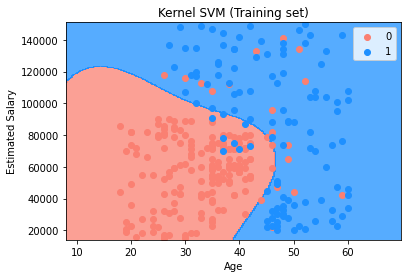

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results

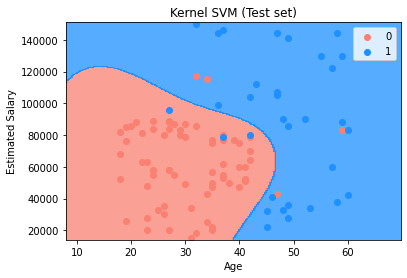

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()